In [1]:
import os 
from glob import glob

import IPython.display as ipd

import scipy 
import sklearn
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# pip install librosa==0.9.2

# Task 1

In [3]:
def draw_waveform(wav, sr, figsize=(14, 5)):
    plt.figure(figsize=figsize)
    librosa.display.waveshow(wav, sr=sr)
    ipd.Audio(wav, rate=sr)
    plt.show()

In [4]:
wav, sr = librosa.load("waves_yesno/0_1_0_1_1_1_0_0.wav")

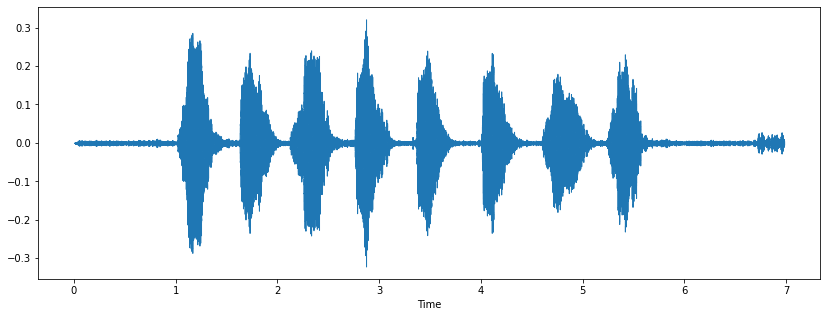

In [5]:
draw_waveform(wav, sr)

In [6]:
ipd.Audio(wav, rate=sr)

## Task 2

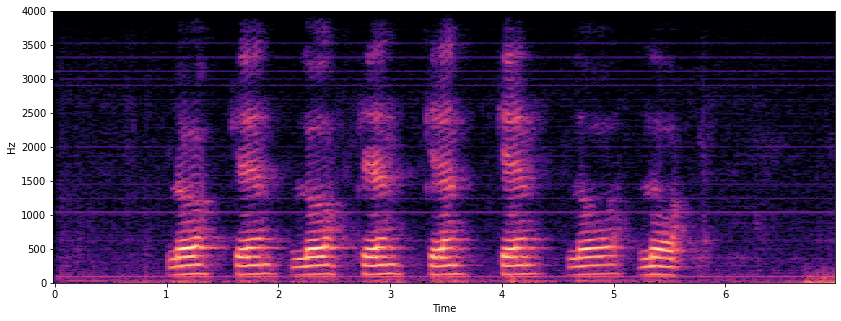

In [7]:
stft = librosa.stft(wav)
stft_db = librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(14, 5))
librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz');
plt.ylim(0, 4000);

## Task 3

In [8]:
def load_dataset(directory: str):
    """

    :param directory: Путь к директории с аудио
    :return:
        X - Список аудио сигналов
        labels - Список меток (Например для файла '0_0_0_1_0_1_1_0.wav': [0, 0, 0, 1, 0, 1, 1, 0])
        sr - частоты дискретизаций аудио файлов
        files - Названия файлов
    """
    X, labels, sr, files = [], [], [], []
    for f in glob(directory + "/*.wav"):
        filename = os.path.basename(f)
        name = filename[:-4]
        y = [int(label) for label in name.split("_")]
        x, sr = librosa.load(f)
        X.append(x)
        labels.append(y)
        files.append(filename)

    return X, labels, sr, files

In [9]:
X, Y, sr, files = load_dataset("waves_yesno")

In [10]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [102]:
X_files, X_files, Y_train, Y_test = train_test_split(files, Y, test_size=0.2, random_state=42)

In [103]:
len(X_train)

47

In [104]:
len(X_test)

12

In [105]:
Y_train[0]

[0, 0, 1, 1, 1, 0, 0, 1]

In [87]:
X_files[0]

'0_0_1_0_0_0_1_0.wav'

## Task 4

In [88]:
import math
from scipy.signal import butter, lfilter, freqz

In [211]:
class VAD():
    
    def __init__(self, signal, sr, window_ms=0.05, high_freq=600, speechlen=4000):
        self.signal = signal
        self.sr = sr
        self.fmax = sr / 2
        self.window_ms = window_ms
        self.high_freq = high_freq
        self.speechlen = speechlen
        
    def butter_lowpass(self, cutoff, order=5):
        nyq = 0.5 * self.sr
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        return b, a

    def butter_lowpass_filter(self, cutoff, order=5):
        b, a = self.butter_lowpass(cutoff, order=order)
        y = lfilter(b, a, self.signal)
        self.signal = y
        self.fmax = cutoff

    def window(self):
        winsize = int(self.window_ms * self.sr)
        fltr = np.ones(winsize)
        result = np.convolve(abs(self.signal), fltr) / np.sum(fltr)
        result /= result.max()
        self.energy = result ** 2

    def smooth(self, result, speechlen):
        diff = np.diff(result)
        index = np.where(diff != 0)[0]
        l = []
        for i in range(0, len(index), 2):
            voice_len = index[i + 1] - index[i]
            if voice_len < speechlen:
                result[index[i] - 1000:index[i + 1]] = 0
        start = np.where(np.diff(result) == 1)[0]
        stop = np.where(np.diff(result) == -1)[0]
        segments = [[x, y] for x, y in zip(start, stop)]
        return result, segments

    def find_voice(self, threshold=1000):
        
        self.butter_lowpass_filter(self.high_freq)
        self.window()
        winsize = int(self.window_ms * self.sr)    
        result = (self.energy >= threshold).astype(int)
        fltr = np.ones(winsize)
        result = np.convolve(self.energy, fltr) / np.sum(fltr)
        result /= result.max()        
        result = np.where(result < np.median(result) * 2, 0, 1)
        result, segments = self.smooth(result, self.speechlen)
        print(segments)
        self.voice = result
        
        return result, segments

    def plot_wave(self):
        plt.figure(figsize=(21, 6))
        plt.plot(self.signal)
        plt.show()
        
    def plot_voice(self, text):
        plt.figure(figsize=(21, 6))
        plt.plot(self.voice, 'r', label='Voice_detected')
        plt.plot(self.signal, 'b', label='Origin signal', alpha=0.5)
        plt.legend(loc="best")
        plt.title(text)
        plt.show()  
        
    def plot_stft(self):
        plt.figure(figsize=(21, 6))
        f, t, Zxx = scipy.signal.stft(self.signal, self.sr, nperseg=1000)
        plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
        plt.title('STFT Magnitude')
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.ylim(0, self.fmax)
        plt.show()

In [212]:
X_train[0].shape

(141120,)

In [218]:
x, sr = librosa.load('waves_yesno/0_0_0_1_0_1_1_0.wav') 

In [219]:
x.shape

(134726,)

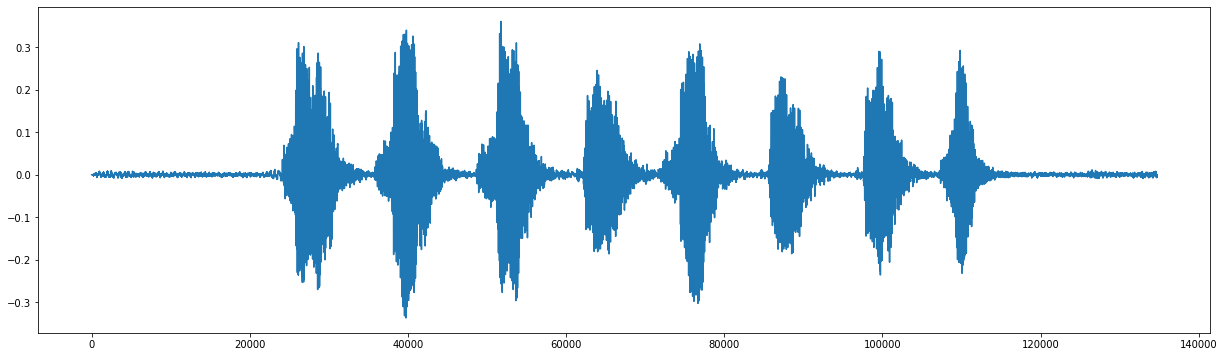

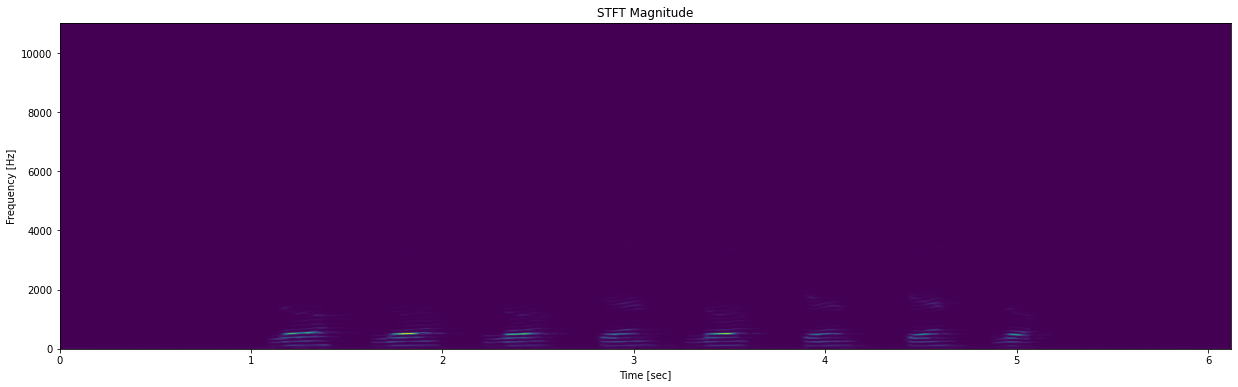

In [220]:
test = VAD(x, sr)
test.plot_wave()
test.plot_stft()

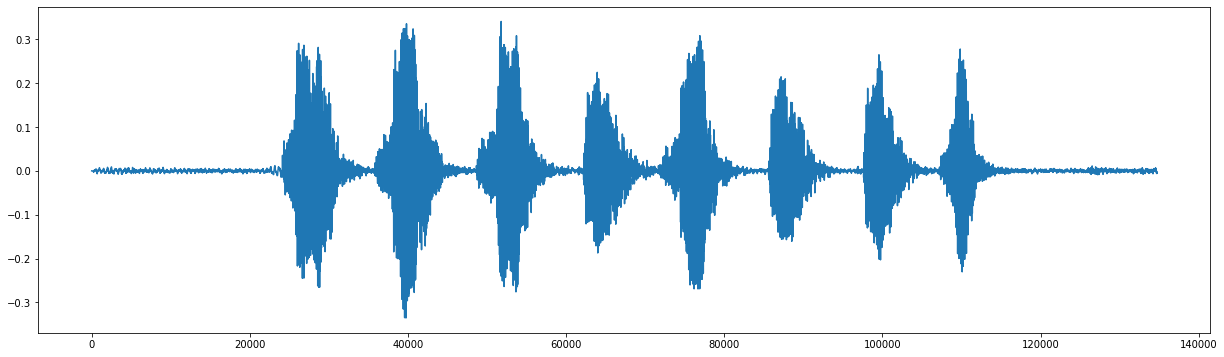

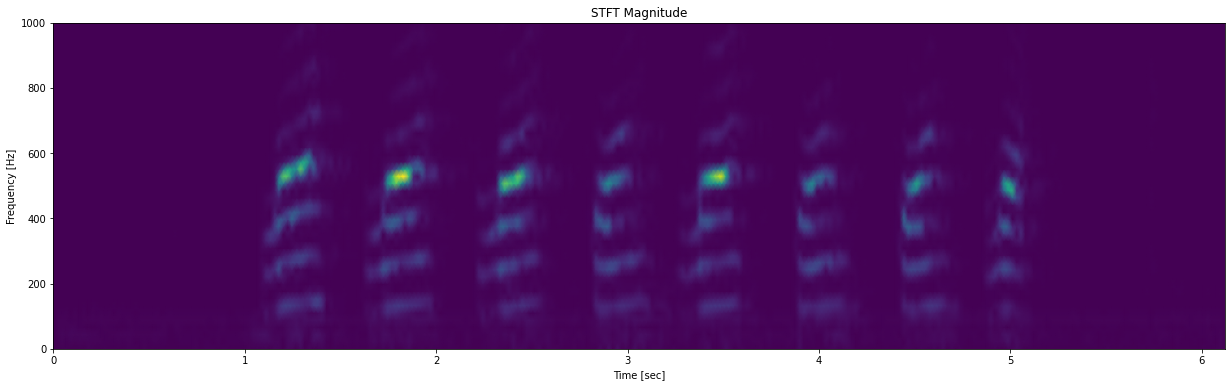

In [221]:
test.butter_lowpass_filter(1000)
test.plot_wave()
test.plot_stft()

[[24766, 33267], [36850, 45762], [49728, 58362], [62783, 70427], [73120, 81625], [86255, 93284], [98188, 105125], [108446, 114008]]


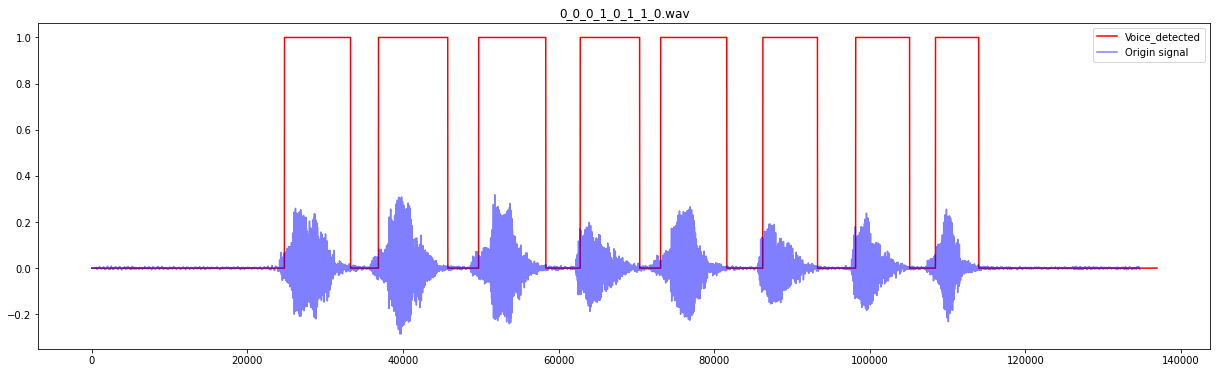

In [222]:
test.find_voice(100)
test.plot_voice(f'0_0_0_1_0_1_1_0.wav')

In [ ]:
test

In [209]:
train_VA = [VAD(x, sr).find_voice(800)[1] for x in X_train]
test_VA  = [VAD(x, sr).find_voice(800)[1] for x in X_test]

## Task 5

In [22]:
def make_dataset(samples, labels, vad_segments):
    """

    :param samples: Список аудио сигналов
    :param labels: Список меток (Например для файла '0_0_0_1_0_1_1_0.wav': [0, 0, 0, 1, 0, 1, 1, 0])
    :param vad_segments: Список сегментов для каждого аудио сигнала вида:
        [
            [[23996, 32539], [35410, 44925], ...,],
            [[22141, 30259], [34917, 42695], ...,],
            ...
        ]
    :return:
    """
    X, y = [], []
    # Проходим по каждому аудио сигналу
    for sample in range(len(samples)):
        # В аудио сигнале проходим по каждому сегменту с речью
        for segment in range(len(vad_segments[sample]) - 1):
            start = vad_segments[sample][segment][0]  # Начало сегмента
            stop = vad_segments[sample][segment][1]  # Конец сегмента
            voice = samples[sample][start:stop]  # Отрезаем сегмент с речью из аудио сигнала и применяем stft
            stft = librosa.stft(voice).mean(axis=1)
            stft_db = librosa.amplitude_to_db(abs(stft))

            X.append(stft_db)  # Добавляем спектрограмму с речью
            y.append(labels[sample][segment])  # Добавляем метку для этой спектрограммы

    return np.array(X), np.array(y)

In [23]:
train_X, train_y = make_dataset(X_train, Y_train, train_VA)
test_X, test_y   = make_dataset(X_test,  Y_test,  test_VA)

In [24]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

classifier = SVC(random_state = 0)

classifier.fit(train_X, train_y);

In [25]:
print('Accuracy train: ', classifier.score(train_X, train_y))

Accuracy train:  0.9877300613496932


In [26]:
print('Accuracy test: ', classifier.score(test_X, test_y))

Accuracy test:  1.0


In [28]:
logreg = LogisticRegression(random_state=0).fit(train_X, train_y)

/opt/conda/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
print('Accuracy train: ', logreg.score(train_X, train_y))

Accuracy train:  1.0


In [30]:
print('Accuracy test: ', logreg.score(test_X, test_y))

Accuracy train:  0.9761904761904762
